# Customer Investment Needs — Modeling

**Goal:** Train binary classifiers for each investment target, build an entropy-gated soft-vote ensemble, and flag uncertain predictions for human review using KNN neighbourhood disagreement.

**Inputs:** `processed_features.xlsx` — output of `0-DataPreprocessing.ipynb`

**Outputs:** `model_predictions.xlsx` — per-customer probabilities, ensemble predictions, and review flags — consumed by `02_next_best_action_system_design.ipynb`

> **Note:** Plots are defined in `plots.py` in the same directory.

---

## Notebook Structure

1. Imports & Setup
2. Load Processed Data
3. Scaling
4. Distance Matrix Construction
5. Train / Test Split
6. Custom Scorer
7. Modeling
8. Entropy-Gated Ensemble
9. KNN Uncertainty Flagging
10. SHAP Explainability
11. Export

---
## 1. Imports & Setup

In [20]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import plots
from models import ModelFactory
from utilities import (
    display_results_table,
    plot_model_diagnostics,
)


importlib.reload(plots)

sns.set_theme(style="darkgrid", context="notebook", palette="muted")
plt.rcParams.update({
    "figure.dpi":       110,
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor":   "#16213e",
    "text.color":       "#e0e0e0",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#e0e0e0",
    "ytick.color":      "#e0e0e0",
})

SEED    = 42
TARGETS = ["IncomeInvestment", "AccumulationInvestment"]

---
## 2. Load Processed Data

Two sheets from `processed_features.xlsx`:
- `features` — engineered features
- `targets`  — two binary labels

In [21]:
input_path = "processed_features.xlsx"

feature_df = pd.read_excel(input_path, sheet_name="features", index_col=0)
targets_df = pd.read_excel(input_path, sheet_name="targets",  index_col=0)

print("features :", feature_df.shape)
print("targets  :", targets_df.shape)
print("\nClass balance:")
print(targets_df.mean().round(3))
feature_df.head()

features : (5000, 8)
targets  : (5000, 2)

Class balance:
IncomeInvestment          0.384
AccumulationInvestment    0.513
dtype: float64


,Age,FamilyMembers,FinancialEducation,RiskPropensity,Wealth_log,Income_log,IncomePerFamilyMember_log,Income_Wealth_Ratio_log
0,64,3,0.563402,0.582442,5.122047,5.048320,3.962466,0.656742
1,57,2,0.197647,0.396081,4.219891,4.228070,3.549398,0.697306
2,53,2,0.404948,0.407098,3.602428,3.398944,2.738659,0.593727
3,67,3,0.610428,0.332732,4.726979,4.620627,3.541516,0.640910
4,57,3,0.507142,0.501799,4.122068,4.141433,3.074125,0.703036


In [22]:
# Separate numerical and categorical columns for downstream use
NUMERICAL_FEATURES   = feature_df.select_dtypes(include="number").columns.tolist()
CATEGORICAL_FEATURES = feature_df.select_dtypes(exclude="number").columns.tolist()

print("Numerical  :", NUMERICAL_FEATURES)
print("Categorical:", CATEGORICAL_FEATURES)

Numerical  : ['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log']
Categorical: []


---
## 3. Scaling

All variables are standardised to comparable ranges.  Ordinal features like
`FamilyMembers` are also scaled to ensure balanced contribution to distance
computation.

In [23]:
scaler = StandardScaler()

feature_scaled_df = feature_df.copy()
feature_scaled_df[NUMERICAL_FEATURES] = scaler.fit_transform(feature_df[NUMERICAL_FEATURES])

print("Scaled means (should be ~0):")
print(feature_scaled_df[NUMERICAL_FEATURES].mean().round(3))
print("\nScaled stds (should be ~1):")
print(feature_scaled_df[NUMERICAL_FEATURES].std().round(3))

Scaled means (should be ~0):
Age                          0.0
FamilyMembers               -0.0
FinancialEducation          -0.0
RiskPropensity               0.0
Wealth_log                  -0.0
Income_log                   0.0
IncomePerFamilyMember_log   -0.0
Income_Wealth_Ratio_log     -0.0
dtype: float64

Scaled stds (should be ~1):
Age                          1.0
FamilyMembers                1.0
FinancialEducation           1.0
RiskPropensity               1.0
Wealth_log                   1.0
Income_log                   1.0
IncomePerFamilyMember_log    1.0
Income_Wealth_Ratio_log      1.0
dtype: float64


---
## 4. Distance Matrix Construction

All features are numerical and standardised, so we use Euclidean distance.
The resulting distance matrix feeds the KNN-based uncertainty-flagging step.

> **Design note:** Feature scaling and weighting are as important as model
> choice in distance-based systems.  Later stages may introduce feature weights
> to reflect financial relevance (e.g. risk propensity, income).

In [24]:
distance_matrix = pairwise_distances(feature_scaled_df, metric="euclidean")

print(f"Distance matrix shape : {distance_matrix.shape}")
print(f"Value range           : [{distance_matrix.min():.4f}, {distance_matrix.max():.4f}]")
print(f"Mean distance         : {distance_matrix.mean():.4f}")

# Sanity check — diagonal must be zero (self-distance)
assert np.allclose(np.diag(distance_matrix), 0, atol=1e-6),     "Diagonal is not zero — check implementation."
print("Diagonal check        : OK")

Distance matrix shape : (5000, 5000)
Value range           : [0.0000, 19.9891]
Mean distance         : 3.6984
Diagonal check        : OK


---
## 5. Train / Test Split

Stratified 80/20 split applied once and reused across all models for
comparable evaluation.  Stratification preserves class balance in both splits.

In [25]:
income_series = targets_df["IncomeInvestment"]
accum_series  = targets_df["AccumulationInvestment"]

# Income target
X_train_inc, X_test_inc, y_income_train, y_income_test = train_test_split(
    feature_scaled_df, income_series,
    test_size=0.2, random_state=SEED, stratify=income_series,
)

# Accumulation target
X_train_acc, X_test_acc, y_accum_train, y_accum_test = train_test_split(
    feature_scaled_df, accum_series,
    test_size=0.2, random_state=SEED, stratify=accum_series,
)

print(f"Income     — train: {len(X_train_inc):,}  test: {len(X_test_inc):,}")
print(f"Accumulation — train: {len(X_train_acc):,}  test: {len(X_test_acc):,}")

Income     — train: 4,000  test: 1,000
Accumulation — train: 4,000  test: 1,000


---
## 6. Custom Scorer

Standard accuracy ignores class imbalance.  We provide two alternatives:

1. **`constrained_recall_scorer`** — returns −1 (hard penalty) if class-0 recall
   falls below a configurable floor; otherwise returns accuracy.  We don't want to
   blindly recommend products to everyone.
2. **`balanced_recall_accuracy`** — a weighted blend:
   `α · recall(class=1) + (1−α) · accuracy` (professor's suggestion, `α=0.7`).

The floor differs by target (tighter for `Accumulation`, looser for `Income`) —
tune after inspecting the baseline confusion matrices.

> **Professor suggestion:** Test both and check which is more stable across folds.

In [26]:
from sklearn.metrics import make_scorer


def constrained_recall_scorer(y_true, y_pred, recall_floor: float = 0.6):
    """
    Returns accuracy if class-0 recall >= recall_floor, else -1.
    Wrap with make_scorer(constrained_recall_scorer) for sklearn CV.
    """
    # TODO: implement
    pass


def balanced_recall_accuracy(y_true, y_pred, alpha: float = 0.7):
    """
    Weighted blend: alpha * recall(class=1) + (1-alpha) * accuracy.
    """
    # TODO: implement
    pass

In [27]:
def run_experiment(model_key, feature_type, X_train, y_train, X_test, y_test, tune=False):
    """
    Create, optionally tune, evaluate, train final model, and plot diagnostics.
    """

    model = ModelFactory.create(model_key)

    # 1. Optional tuning (must happen BEFORE evaluation/training)
    if tune:
        model.tune(X_train, y_train)

    # 2. Evaluate using base model (CV + test)
    results = model.evaluate(X_train, y_train, X_test, y_test)
    display_results_table(results, model.name, feature_type)

    # 3. Train final model on full training data
    model.train(X_train, y_train)

    # 4. Predictions
    y_pred = model.predict(X_test)

    # 5. Probabilities (safe handling)
    if hasattr(model.trained_model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    # 6. Diagnostics (only if probabilities exist)
    plot_model_diagnostics(
        y_test,
        y_pred,
        y_prob,
        model.name,
        feature_type,
    )

    return model, results, y_prob

---
## 7. Modeling

Train classifiers for each target, then optionally tune hyperparameters.
Each model outputs:
- Hard prediction `y_pred`
- Class-1 probability `p` — used in the ensemble and entropy gate

Store per-model probabilities in a results dict keyed by model name.

### 7.1 Logistic Regression

Uses scaled features.  Grid: `L1`, `L2`, `elasticnet` penalties via
`GridSearchCV` with the custom scorer.

> **Professor suggestion:** `L1` with `C=0.01` (strong regularisation) performed
> best for `IncomeInvestment` — a good starting point.


LogisticRegression — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.76   | 0.016  |  0.785   |
| Precision |  0.759  | 0.017  |  0.787   |
|  Recall   |  0.76   | 0.016  |  0.785   |
|    F1     |  0.75   | 0.017  |  0.777   |
+-----------+---------+--------+----------+


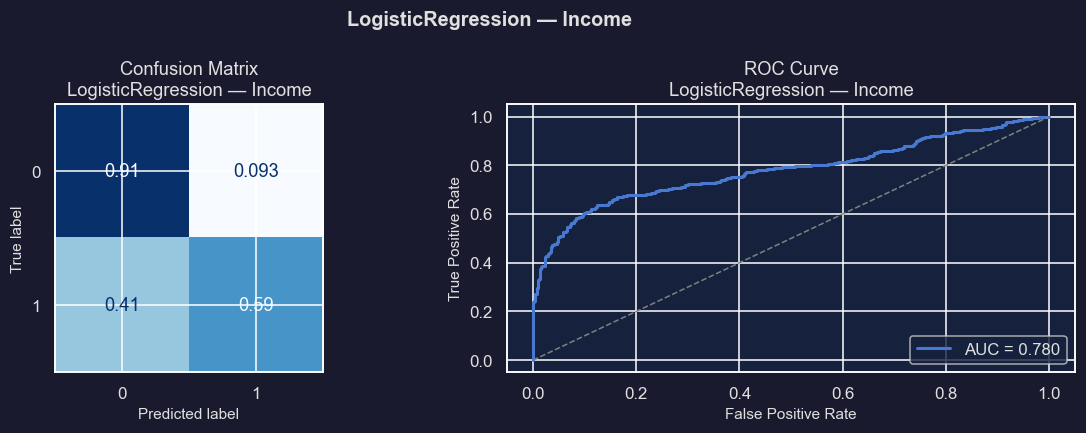


LogisticRegression — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.658  | 0.019  |   0.67   |
| Precision |  0.658  | 0.019  |   0.67   |
|  Recall   |  0.658  | 0.019  |   0.67   |
|    F1     |  0.656  |  0.02  |  0.669   |
+-----------+---------+--------+----------+


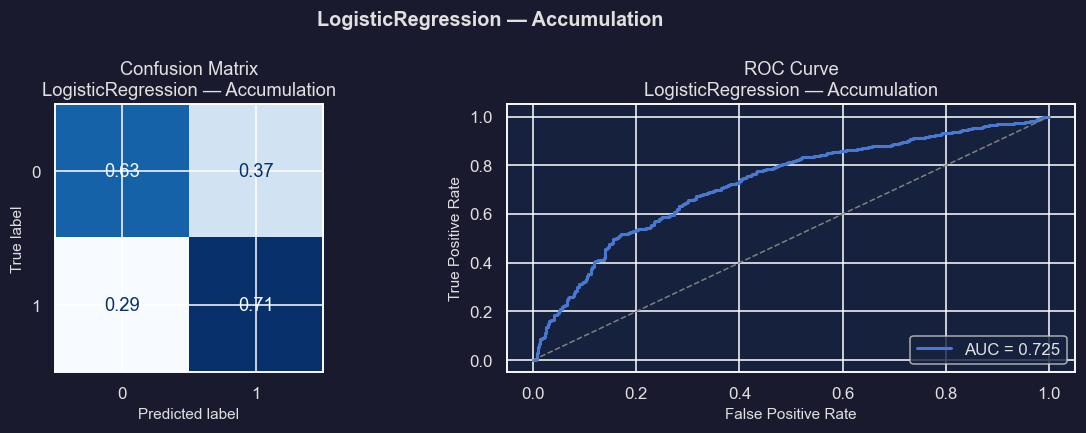

In [28]:
income_model, income_results, income_prob = run_experiment(
    "logistic", "Income",
    X_train_inc, y_income_train, X_test_inc, y_income_test,
    tune=False,
)
accum_model,  accum_results, accum_prob  = run_experiment(
    "logistic", "Accumulation",
    X_train_acc, y_accum_train, X_test_acc, y_accum_test,
    tune=False,
)

### 7.2 XGBoost

Key hyperparameters: `max_depth`, `learning_rate`, `n_estimators`,
`scale_pos_weight` (handles imbalance).

> **Professor suggestion:** Start with `scale_pos_weight = count(0) / count(1)`,
> then tune `gamma` and `min_child_weight` to control overfitting.


XGBoost — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.791  | 0.011  |  0.806   |
| Precision |  0.792  | 0.012  |  0.809   |
|  Recall   |  0.791  | 0.011  |  0.806   |
|    F1     |  0.784  | 0.011  |  0.799   |
+-----------+---------+--------+----------+


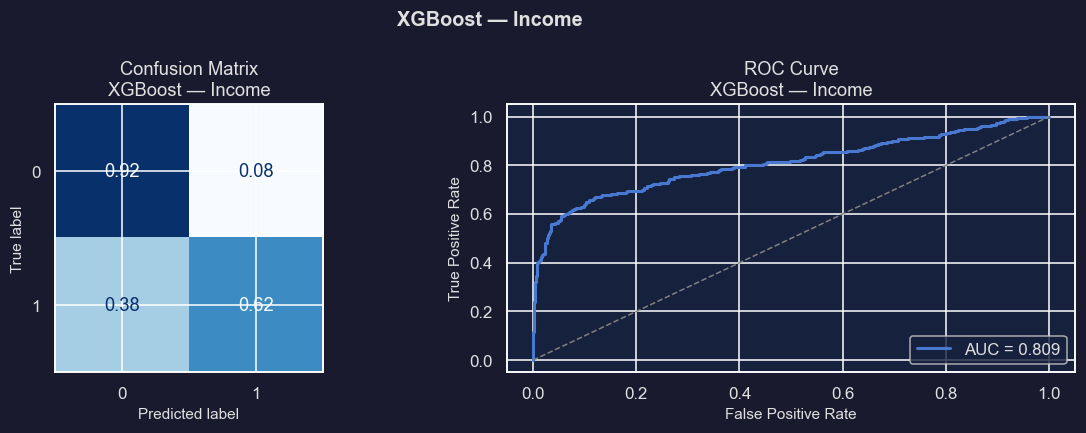


XGBoost — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.806  | 0.013  |  0.811   |
| Precision |  0.812  | 0.016  |  0.821   |
|  Recall   |  0.806  | 0.013  |  0.811   |
|    F1     |  0.805  | 0.013  |   0.81   |
+-----------+---------+--------+----------+


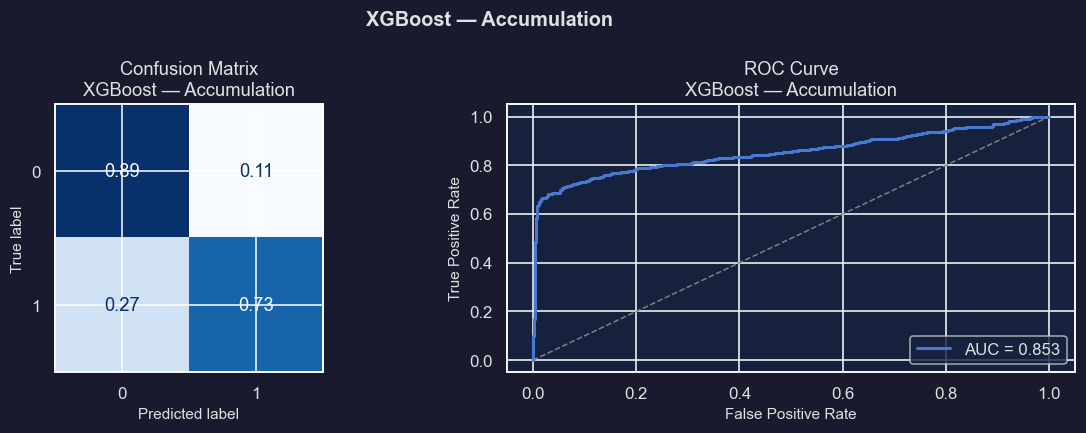

In [29]:
income_model, income_results, income_prob= run_experiment(
    "xgb", "Income",
    X_train_inc, y_income_train, X_test_inc, y_income_test,
    tune=False,
)
accum_model,  accum_results, accum_prob = run_experiment(
    "xgb", "Accumulation",
    X_train_acc, y_accum_train, X_test_acc, y_accum_test,
    tune=False,
)

### 7.3 Random Forest

Focus the grid on `max_features`, `min_samples_leaf`, `min_samples_split`.

> **Professor suggestion:** `max_features=0.8` (80 % of features per split)
> consistently outperformed `sqrt` on this dataset.


RandomForest — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.816  | 0.015  |  0.828   |
| Precision |  0.827  | 0.017  |  0.841   |
|  Recall   |  0.816  | 0.015  |  0.828   |
|    F1     |  0.807  | 0.016  |   0.82   |
+-----------+---------+--------+----------+


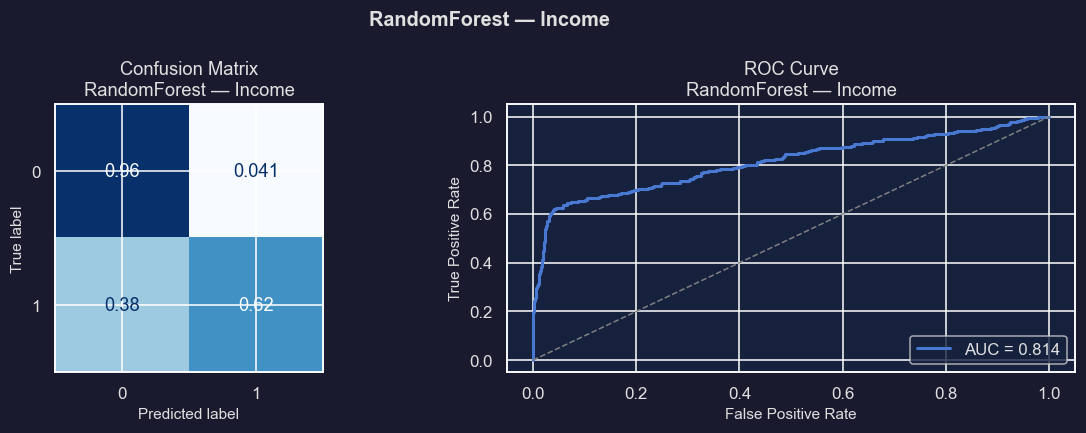


RandomForest — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.829  | 0.013  |  0.822   |
| Precision |  0.839  | 0.015  |  0.835   |
|  Recall   |  0.829  | 0.013  |  0.822   |
|    F1     |  0.828  | 0.013  |  0.821   |
+-----------+---------+--------+----------+


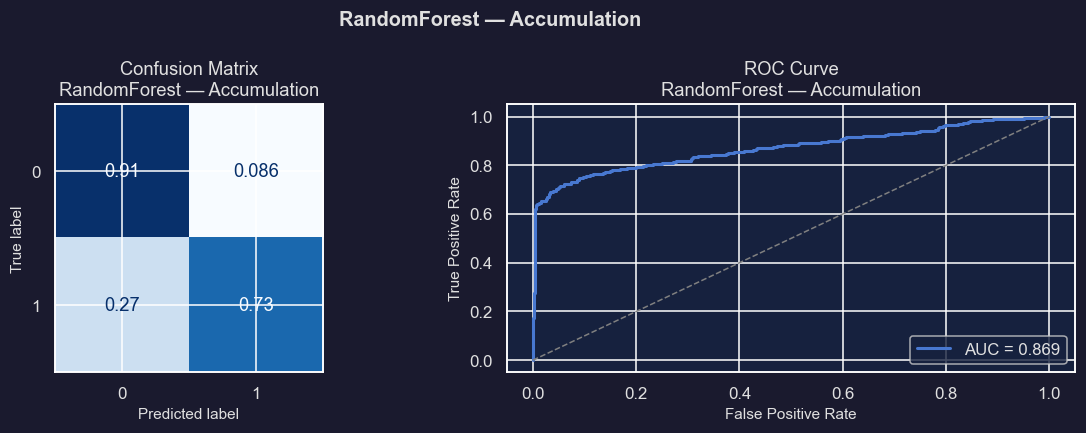

In [30]:
income_model, income_results, income_prob = run_experiment(
    "rf", "Income",
    X_train_inc, y_income_train, X_test_inc, y_income_test,
    tune=True,
)
accum_model,  accum_results, accum_prob  = run_experiment(
    "rf", "Accumulation",
    X_train_acc, y_accum_train, X_test_acc, y_accum_test,
    tune=True,
)

### 7.4 MLP (PyTorch)

Architecture:
`Linear(n→64) → BatchNorm → ReLU → Dropout(0.2) →
 Linear(64→32) → BatchNorm → ReLU → Dropout(0.2) →
 Linear(32→1) → Sigmoid`

> **Professor suggestion:** For this dataset size the MLP rarely outperforms
> XGBoost, but it adds diversity to the ensemble — worth keeping for probability
> averaging even if standalone performance is lower.

In [31]:
# TODO: implement PyTorch MLP model and training loop

### 7.5 Naive Baysian Model


GaussianNB — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.732  | 0.014  |  0.748   |
| Precision |  0.732  | 0.015  |  0.747   |
|  Recall   |  0.732  | 0.014  |  0.748   |
|    F1     |  0.732  | 0.015  |  0.747   |
+-----------+---------+--------+----------+


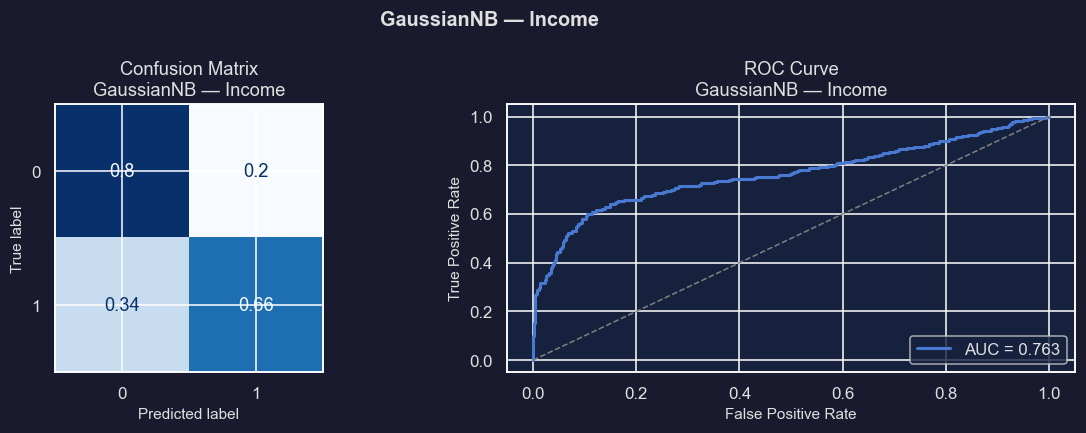


GaussianNB — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.64   | 0.013  |  0.648   |
| Precision |  0.644  | 0.013  |  0.651   |
|  Recall   |  0.64   | 0.013  |  0.648   |
|    F1     |  0.635  | 0.014  |  0.644   |
+-----------+---------+--------+----------+


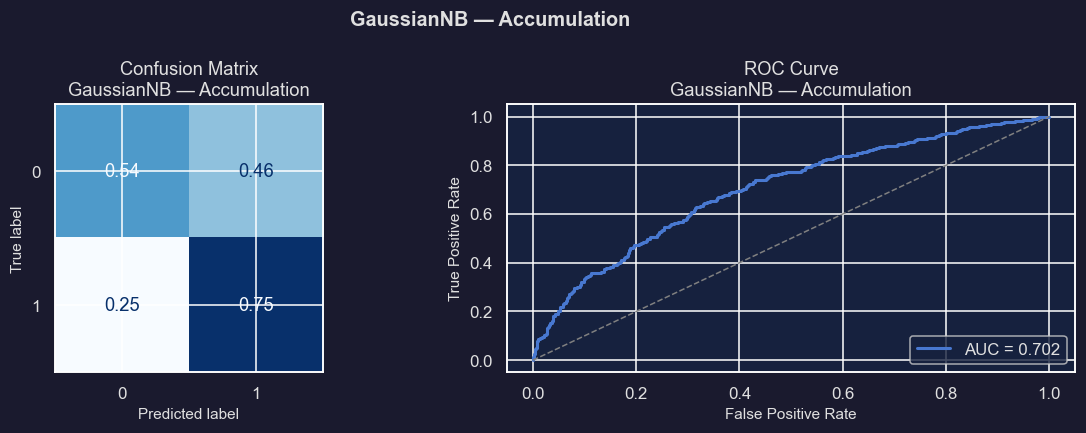

In [39]:
income_model, income_results, income_prob = run_experiment(
    "gnb", "Income",
    X_train_inc, y_income_train, X_test_inc, y_income_test,
    tune=False,
)
accum_model,  accum_results, accum_prob  = run_experiment(
    "gnb", "Accumulation",
    X_train_acc, y_accum_train, X_test_acc, y_accum_test,
    tune=False,
)

### 7.6 KNN Model


KNN — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.743  | 0.012  |  0.766   |
| Precision |  0.739  | 0.013  |  0.765   |
|  Recall   |  0.743  | 0.012  |  0.766   |
|    F1     |  0.735  | 0.013  |  0.758   |
+-----------+---------+--------+----------+


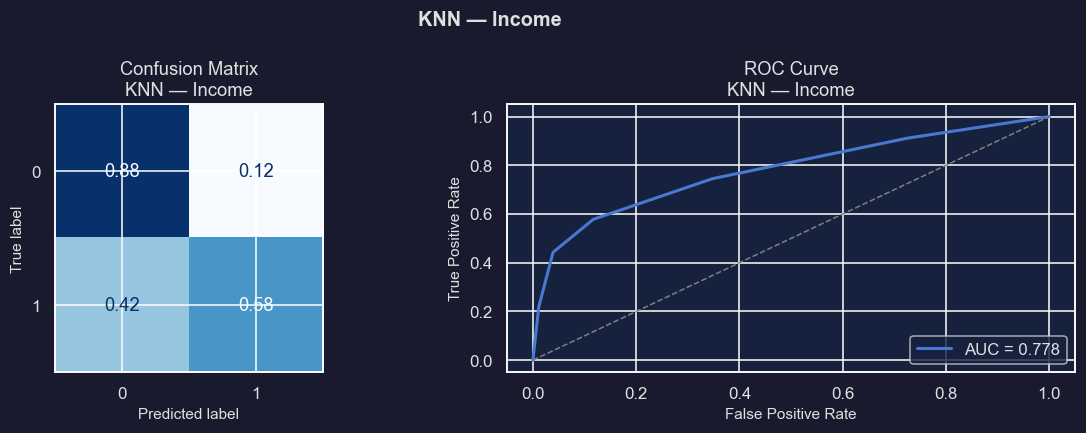


KNN — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.728  | 0.012  |  0.756   |
| Precision |  0.73   | 0.012  |  0.759   |
|  Recall   |  0.728  | 0.012  |  0.756   |
|    F1     |  0.728  | 0.012  |  0.756   |
+-----------+---------+--------+----------+


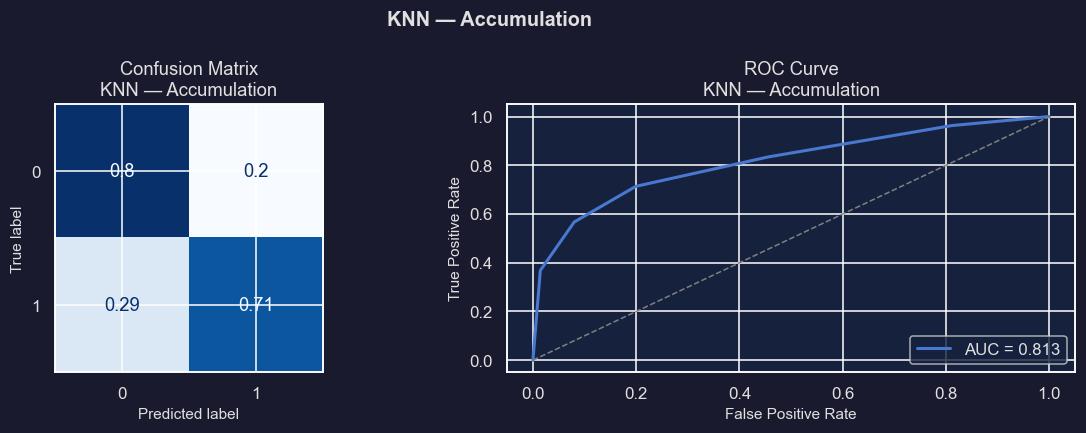

In [40]:
income_model, income_results, income_prob = run_experiment(
    "knn", "Income",
    X_train_inc, y_income_train, X_test_inc, y_income_test,
   # tune=True,
)
accum_model,  accum_results, accum_prob  = run_experiment(
    "knn", "Accumulation",
    X_train_acc, y_accum_train, X_test_acc, y_accum_test,
  #  tune=True,
)

### SVM Model


SVM — Income
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.781  | 0.011  |  0.797   |
| Precision |  0.792  | 0.011  |   0.81   |
|  Recall   |  0.781  | 0.011  |  0.797   |
|    F1     |  0.768  | 0.012  |  0.785   |
+-----------+---------+--------+----------+


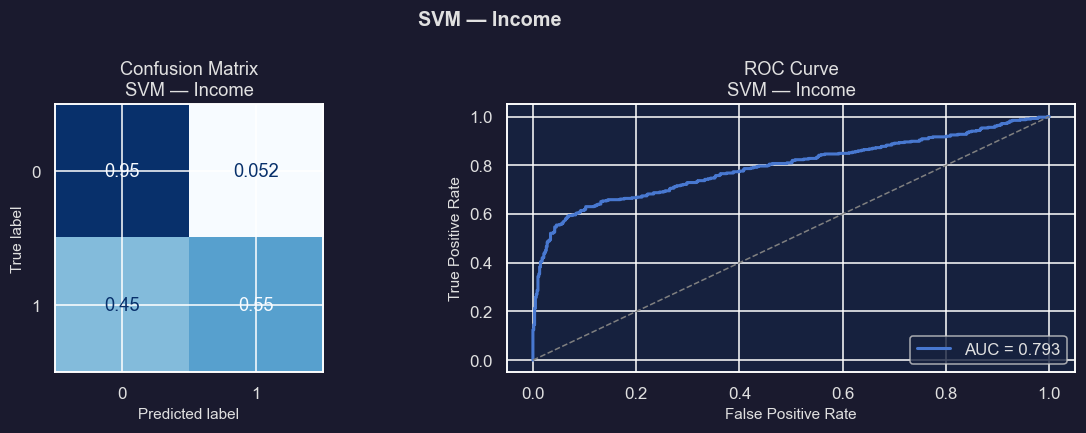


SVM — Accumulation
+-----------+---------+--------+----------+
|  Metric   | CV Mean | CV Std | Test Set |
+-----------+---------+--------+----------+
| Accuracy  |  0.772  |  0.02  |  0.789   |
| Precision |  0.776  | 0.021  |  0.796   |
|  Recall   |  0.772  |  0.02  |  0.789   |
|    F1     |  0.771  |  0.02  |  0.788   |
+-----------+---------+--------+----------+


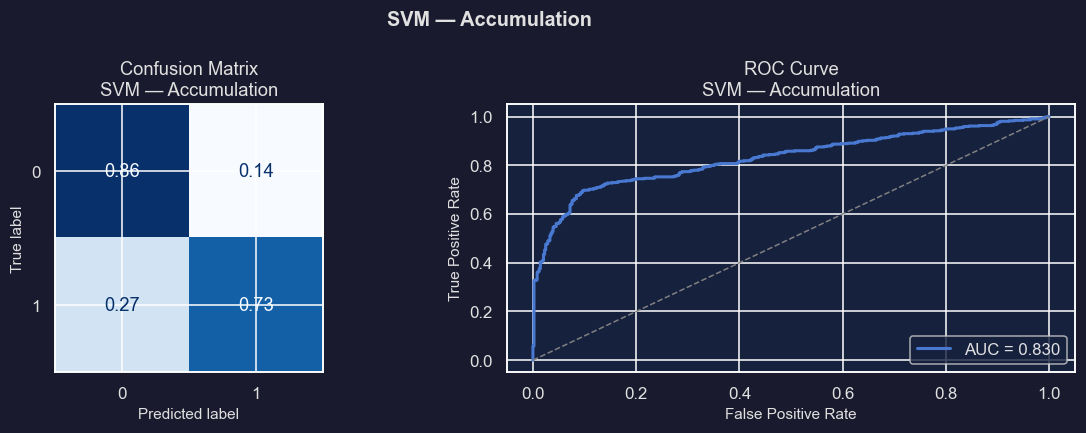

In [41]:
income_model, income_results, income_prob = run_experiment(
    "svm", "Income",
    X_train_inc, y_income_train, X_test_inc, y_income_test,
   # tune=True,
)
accum_model,  accum_results, accum_prob  = run_experiment(
    "svm", "Accumulation",
    X_train_acc, y_accum_train, X_test_acc, y_accum_test,
   # tune=True,
)

### 7.6 Per-model comparison — `IncomeInvestment`

> **TODO:** Print classification reports side by side.  Plot ROC curves on the
> same axes.  Identify which model has the best recall–precision trade-off.

In [32]:
# TODO: side-by-side comparison

---
## 8. Entropy-Gated Ensemble

Instead of plain soft-voting (equal weights), each model's probability is
weighted by its **inverse entropy** — confident models contribute more.

For a binary classifier outputting `p`:
$$H = -p \log p - (1-p) \log(1-p)$$

Weight per model per sample: $w_m = 1 - H_m$, then normalise across models.

Final ensemble probability:
$$\hat{p}_{\text{ensemble}} = \sum_m w_m \cdot p_m \;/\; \sum_m w_m$$

> **Extension:** Compare entropy-gated weights vs. equal weights vs.
> validation-AUC weights.  Does the gating actually help, or is model diversity
> too low to matter?

In [33]:
def binary_entropy(p: np.ndarray) -> np.ndarray:
    """Shannon entropy of a Bernoulli(p) variable. Shape-preserving."""
    # Clip away from 0 and 1 to avoid log(0)
    # TODO: implement
    pass


def entropy_gated_ensemble(prob_dict: dict) -> np.ndarray:
    """
    Entropy-gated soft-vote ensemble.

    Parameters
    ----------
    prob_dict : dict[str, np.ndarray]
        {model_name: class-1 probabilities}, each shape (n,)

    Returns
    -------
    np.ndarray, shape (n,) — weighted average probability
    """
    # TODO: implement
    pass

In [34]:
# TODO: call entropy_gated_ensemble for each target
# TODO: threshold at 0.5 to get hard predictions
# TODO: compare ensemble vs best single model on the test set

---
## 9. KNN Uncertainty Flagging

The ensemble gives a confidence score (distance of `p` from 0.5).  But a
confident prediction can still be wrong if the point sits in a **contested
region** of feature space.

We add a second signal: for each point, find its `K` nearest neighbours in
Euclidean space and check whether their **true labels** agree with the ensemble
prediction.  Disagreement flags the point for human review.

**Review flag logic (combine both signals):**
1. Ensemble confidence low: `|p − 0.5| < confidence_threshold`
2. Neighbourhood disagreement high: `label_agreement_among_K_neighbours < agreement_threshold`

A point flagged by either criterion goes to human review.

> **Design choice:** Start with `K=5`, `confidence_threshold=0.15`,
> `agreement_threshold=0.65` and tune on the validation set.

In [35]:
def knn_neighbourhood_agreement(
    distance_matrix: np.ndarray,
    y_true: np.ndarray,
    y_pred_ensemble: np.ndarray,
    K: int = 5,
) -> np.ndarray:
    """
    For each point, compute the fraction of its K nearest neighbours
    (by Euclidean distance) whose true label matches the ensemble prediction.

    Returns
    -------
    np.ndarray, shape (n,) — agreement rate in [0, 1] per sample
    """
    # Hint: np.argsort(distance_matrix[i])[1:K+1] gives the K nearest
    # neighbours (excluding self at index 0)
    # TODO: implement
    pass


def review_flag(
    ensemble_proba: np.ndarray,
    neighbourhood_agreement: np.ndarray,
    confidence_threshold: float = 0.15,
    agreement_threshold: float = 0.65,
) -> np.ndarray:
    """
    Returns a boolean array — True = flag for human review.
    Flagged if ensemble confidence is low OR neighbourhood agreement is low.
    """
    # TODO: implement
    pass

In [36]:
# TODO: compute neighbourhood_agreement for each target
# TODO: compute review flags
# TODO: print: how many customers flagged? what fraction? error rate vs non-flagged?

---
## 10. SHAP Explainability

Use `shap.TreeExplainer` on the best tree-based model per target
(XGBoost or Random Forest).

Two plots per target:
1. Global bar plot — mean |SHAP| per feature
2. Beeswarm — feature value vs. impact direction

> **Extension:** Compute SHAP values specifically for the flagged customers
> (Section 9) — is there a systematic feature pattern causing model uncertainty?

In [37]:
# TODO: SHAP analysis

---
## 11. Export

In [38]:
# TODO: assemble output DataFrame
# TODO: write to model_predictions.xlsx — one sheet per target + a 'combined' sheet
# TODO: print row count, flag count, and file path

---
## To-Do List

- Find optimal feature weights for the distance metric
- Tune Random Forest hyperparameters for `AccumulationInvestment`
- Implement and evaluate MLP (Section 7.4)
- Implement custom scorers (Section 6)
- Build entropy-gated ensemble (Section 8)
- Build KNN uncertainty flagging (Section 9)
- Add SHAP explainability (Section 10)
- Export final predictions (Section 11)